In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
train_dir = "C:/PneumoniaDetection/dataset/chest_xray/train"
test_dir = "C:/PneumoniaDetection/dataset/chest_xray/test"

img_size = (150, 150)  # Resize images to 150x150 pixels
batch_size = 32  # Number of images to process in each batch

train_datagen = ImageDataGenerator(rescale=1./255, zoom_range=0.2, shear_range=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir, target_size=img_size, batch_size=batch_size, class_mode='binary')
test_data = test_datagen.flow_from_directory(test_dir, target_size=img_size, batch_size=batch_size, class_mode='binary')

print("Data preprocessing completed!")

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Data preprocessing completed!


In [3]:



model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 17, 17, 128)      0

In [4]:
history = model.fit(
    train_data,
    steps_per_epoch=train_data.samples // train_data.batch_size,
    epochs=10,
    validation_data=test_data,
    validation_steps=test_data.samples // test_data.batch_size
)

Epoch 1/10
163/163 [==============================] - 258s 2s/step - loss: 0.3809 - accuracy: 0.8430 - val_loss: 0.6095 - val_accuracy: 0.7664
Epoch 2/10
163/163 [==============================] - 194s 1s/step - loss: 0.2179 - accuracy: 0.9082 - val_loss: 0.5836 - val_accuracy: 0.7862
Epoch 3/10
163/163 [==============================] - 196s 1s/step - loss: 0.2002 - accuracy: 0.9216 - val_loss: 0.2704 - val_accuracy: 0.9030
Epoch 4/10
163/163 [==============================] - 195s 1s/step - loss: 0.1933 - accuracy: 0.9264 - val_loss: 0.4598 - val_accuracy: 0.8257
Epoch 5/10
163/163 [==============================] - 192s 1s/step - loss: 0.1655 - accuracy: 0.9373 - val_loss: 0.3380 - val_accuracy: 0.8816
Epoch 6/10
163/163 [==============================] - 193s 1s/step - loss: 0.1568 - accuracy: 0.9400 - val_loss: 0.3225 - val_accuracy: 0.8799
Epoch 7/10
163/163 [==============================] - 189s 1s/step - loss: 0.1433 - accuracy: 0.9461 - val_loss: 0.2788 - val_accuracy: 0.9243

In [5]:
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_data, steps=test_data.samples // test_data.batch_size)
print(f"Test accuracy: {test_acc * 100:.2f}%")

19/19 [==============================] - 9s 441ms/step - loss: 0.4232 - accuracy: 0.8586
Test accuracy: 85.86%


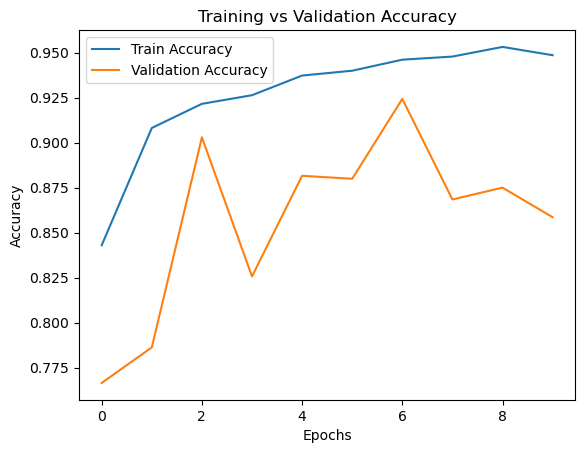

In [6]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

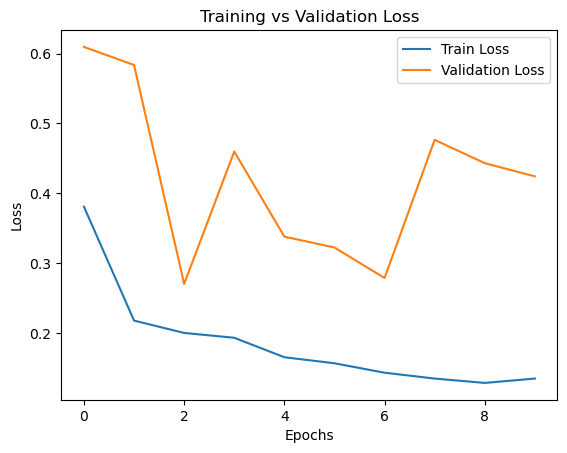

In [7]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [8]:
# Save the trained model
model.save('pneumonia_model.h5')
print("Model saved successfully!")

Model saved successfully!


1/1 [==============================] - 1s 667ms/step


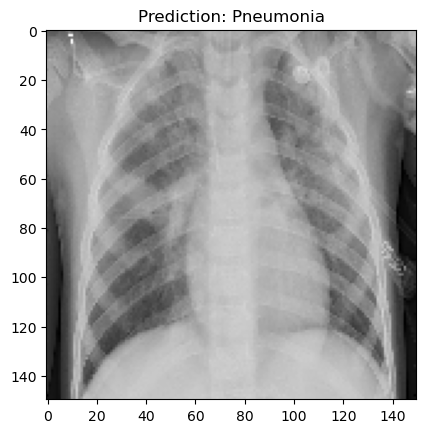

In [9]:
# Load a sample image for prediction
from tensorflow.keras.preprocessing import image

img_path = r'C:\PneumoniaDetection\dataset\chest_xray\test\PNEUMONIA\person3_virus_16.jpeg'
  # Replace with the path to your image
img = image.load_img(img_path, target_size=img_size)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make a prediction (0: Normal, 1: Pneumonia)
prediction = model.predict(img_array)
prediction_class = 'Pneumonia' if prediction[0] > 0.5 else 'Normal'

# Display the image and prediction
plt.imshow(img)
plt.title(f'Prediction: {prediction_class}')
plt.show()